# importações e coleta da base do service da HermesAPI
- considerando que esteja dentro da pasta do Hermes API

In [1]:
from services import DiagnosticosService

In [3]:
base = DiagnosticosService.coleta_base_ML()

In [4]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

C:\Users\caiom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Machine Learn e Modo de Uso
- precisa estar na mesma pasta da hermes api durante a importação para conseguir o uso

In [6]:
df = pd.DataFrame(base)
def extrair_pressao(valor):
    if isinstance(valor, str):
        match = re.match(r"(\d+)[xX/](\d+)", valor)
        if match:
            return int(match.group(1)), int(match.group(2))
    return None, None

df['pressao_sistolica'], df['pressao_diastolica'] = zip(*df['pressao'].map(extrair_pressao))

def limpar_valor(val):
    if isinstance(val, str):
        val = val.replace('%', '').replace('°C', '').replace(',', '.')
        try:
            return float(val)
        except:
            return np.nan
    return val

df['saturacaosangue'] = df['saturacaosangue'].map(limpar_valor)
df['temperatura'] = df['temperatura'].map(limpar_valor)

campos_numericos = ['peso', 'saturacaosangue', 'temperatura', 'pressao_sistolica', 'pressao_diastolica']
df[campos_numericos] = df[campos_numericos].astype(float).fillna(0)

def tratar_cdi(valor):
    if isinstance(valor, list):
        return valor
    return []

df['cdi'] = df['idcdi'].apply(tratar_cdi)

def compor_texto(row):
    return (
        (row['relatoriopessoal'] or "") * 3 + " " +
        (row['observacoesmedicas'] or "") * 3 + " " +
        (row['obsmedica'] or "") * 2 + " " +
        (row['condicoesmedpreexistentes'] or "") + " " +
        (row['historicomedfamiliar'] or "") + " " +
        (row['medicacoesemuso'] or "") + " " +
        (row['restricoes'] or "") + " " +
        (row['examesrealizados'] or "")
    )

df['texto'] = df.apply(compor_texto, axis=1)

tfidf = TfidfVectorizer(max_features=1000)
X_text = tfidf.fit_transform(df['texto'])

X_cdi = np.array(df['cdi'].tolist())
if X_cdi.shape[1] == 0:
    X_cdi = np.zeros((len(df), 1))

scaler = StandardScaler()
X_num = scaler.fit_transform(df[campos_numericos])

X = np.hstack((X_num, X_text.toarray(), X_cdi))
y = df['doenca']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

text_matrix = tfidf.transform(df['texto'])

def prever_doenca(json_input, idcdi_val=None):
    pressao_s, pressao_d = extrair_pressao(json_input.get('pressao', '0x0'))
    saturacao = limpar_valor(json_input.get('saturacaosangue', '0'))
    temperatura = limpar_valor(json_input.get('temperatura', '0'))

    dados_numericos = np.array([[
        json_input.get('peso', 0),
        saturacao,
        temperatura,
        pressao_s or 0,
        pressao_d or 0
    ]])
    dados_numericos = scaler.transform(dados_numericos)

    texto = (
        json_input.get('relatoriopessoal', '') * 3 + " " +
        json_input.get('observacoesmedicas', '') * 3 + " " +
        json_input.get('obsmedica', '') * 2 + " " +
        json_input.get('condicoesmedpreexistentes', '') + " " +
        json_input.get('historicomedfamiliar', '') + " " +
        json_input.get('medicacoesemuso', '') + " " +
        json_input.get('restricoes', '') + " " +
        json_input.get('examesrealizados', '')
    )

    texto_tfidf = tfidf.transform([texto])

    cdi_input = np.array(idcdi_val or [0]).reshape(1, -1)
    if cdi_input.shape[1] != X_cdi.shape[1]:
        cdi_input = np.zeros((1, X_cdi.shape[1]))  # normalizar forma

    vetor_input = np.hstack((dados_numericos, texto_tfidf.toarray(), cdi_input))

    probs = clf.predict_proba(vetor_input)[0]
    classes = clf.classes_
    top3 = sorted(zip(classes, probs), key=lambda x: x[1], reverse=True)[:3]

    similaridade = cosine_similarity(texto_tfidf, text_matrix).flatten()
    indices_similares = similaridade.argsort()[-3:][::-1]
    similares = df.iloc[indices_similares][['doenca', 'medicacao', 'examesrealizados']].to_dict(orient='records')

    return {
        "previsoes": [{"doenca": d, "probabilidade": round(p, 4)} for d, p in top3],
        "explicacao": f"O modelo encontrou padrões fortemente associados às doenças no topo da lista. Foram analisados sintomas, medicamentos em uso e relatórios clínicos.",
        "casos_similares": similares
    }

In [5]:
entrada = {
    "relatoriopessoal": "Dor ao urinar e desconforto abdominal.",
    "observacoesmedicas": "Sensibilidade na região lombar.",
    "obsmedica": "Urina turva, dor ao urinar e febre leve.",
    "pressao": "115x75",
    "saturacaosangue": "80%",
    "peso": 59.0,
    "temperatura": "37.8°C",
    "historicomedfamiliar": "Sem histórico relevante.",
    "condicoesmedpreexistentes": "Candidíase recorrente",
    "medicacoesemuso": "Anticoncepcional oral",
    "restricoes": "Evitar bebidas ácidas",
    "examesrealizados": "EAS, urocultura"
}
res = prever_doenca(entrada)
print(res)

{'previsoes': [{'doenca': 'Infecção urinária', 'probabilidade': 0.96}, {'doenca': 'Bronquite crônica', 'probabilidade': 0.02}, {'doenca': 'Diabetes tipo 2', 'probabilidade': 0.01}], 'explicacao': 'O modelo encontrou padrões fortemente associados às doenças no topo da lista. Foram analisados sintomas, medicamentos em uso e relatórios clínicos.', 'casos_similares': [{'doenca': 'Infecção urinária', 'medicacao': 'Nitrofurantoína 100mg de 6/6h por 7 dias', 'examesrealizados': 'EAS, urocultura'}, {'doenca': 'Infecção urinária', 'medicacao': 'Nitrofurantoína 100mg de 6/6h por 7 dias', 'examesrealizados': 'EAS, urocultura'}, {'doenca': 'Infecção urinária', 'medicacao': 'Nitrofurantoína 100mg de 6/6h por 7 dias', 'examesrealizados': 'EAS, urocultura'}]}


C:\Users\caiom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Resultados

## Cross Validatio
- precisa do HermesAPI

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

scores = cross_validate(
    clf,
    X, y,
    cv=kfold,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    return_train_score=True
)

print("=== Cross Validation ===")
print(f"Acurácia média:        {scores['test_accuracy'].mean():.4f}")
print(f"Precisão média:        {scores['test_precision_macro'].mean():.4f}")
print(f"Recall médio:          {scores['test_recall_macro'].mean():.4f}")
print(f"F1-score médio:        {scores['test_f1_macro'].mean():.4f}")

print(f"\nDesvio padrão (acurácia): {scores['test_accuracy'].std():.4f}")

print("\n=== Relatório por Classe ===")
for train_idx, test_idx in kfold.split(X, y):
    clf.fit(X[train_idx], y[train_idx])
    y_pred = clf.predict(X[test_idx])
    print(classification_report(y[test_idx], y_pred))
    break 


=== Cross Validation (5 folds) ===
Acurácia média:        1.0000
Precisão média:        1.0000
Recall médio:          1.0000
F1-score médio:        1.0000

Desvio padrão (acurácia): 0.0000

=== Relatório por Classe (última fold) ===
                      precision    recall  f1-score   support

   Bronquite crônica       1.00      1.00      1.00        11
     Diabetes tipo 2       1.00      1.00      1.00        11
Hipertensão arterial       1.00      1.00      1.00        14
   Infecção urinária       1.00      1.00      1.00        11
Pneumonia bacteriana       1.00      1.00      1.00        13

            accuracy                           1.00        60
           macro avg       1.00      1.00      1.00        60
        weighted avg       1.00      1.00      1.00        60



foi percebido uma base viciada

## Importancia de features
dando um exemplo da doença com maior certeza de acuracia da base
- precisa do hermes api

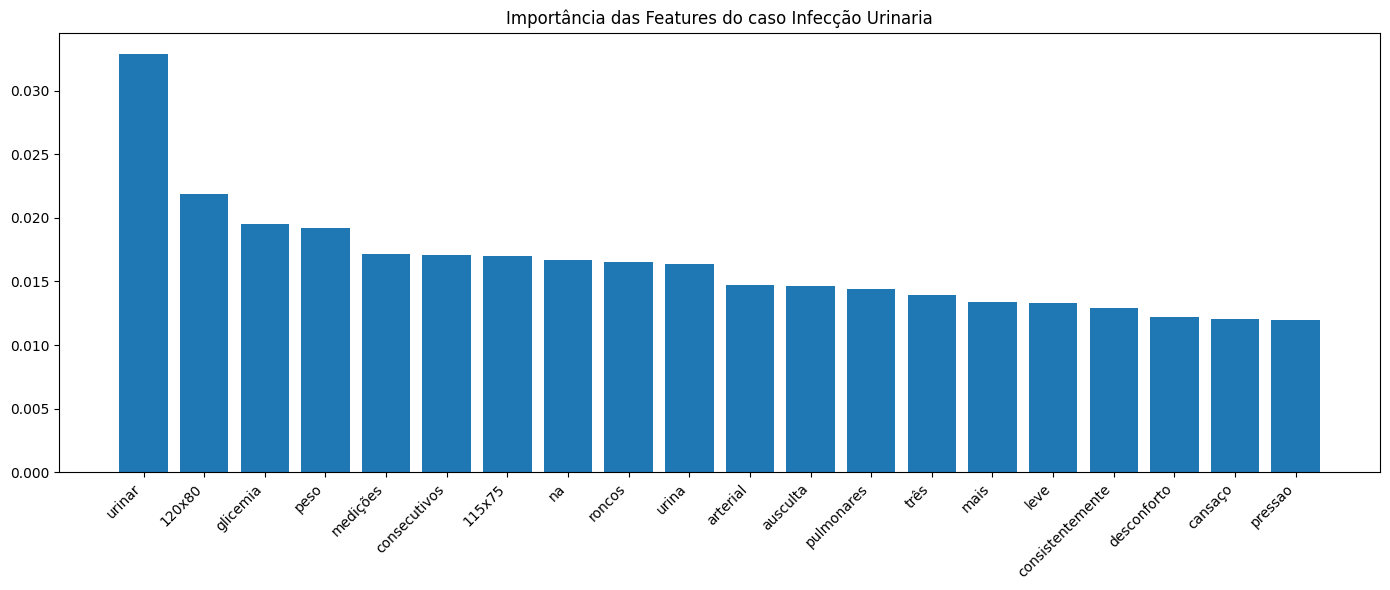

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import numpy as np

X_numerico = df[['pressao', 'peso', 'saturacaosangue']].values

text_data = (
    "pressão: " + df['pressao'].astype(str) + " " +
    df['relatoriopessoal'] + " " +
    df['obsmedica'].fillna("") + " " +
    df['observacoesmedicas'].fillna("")
)

tfidf_vectorizer = TfidfVectorizer(max_features=72)
X_texto = tfidf_vectorizer.fit_transform(text_data).toarray()

X_final = np.hstack([X_numerico, X_texto])

feature_names = ['pressao', 'peso', 'saturacaosangue'] + list(tfidf_vectorizer.get_feature_names_out())


importances = clf.feature_importances_
importances = importances[0:72]
indices = np.argsort(importances)[::-1]
top_n = min(20, len(importances))
plt.figure(figsize=(14, 6))
plt.title("Importância das Features do caso Infecção Urinaria")
plt.bar(range(top_n), importances[indices][:top_n])
plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.tight_layout()
plt.show()



## PDP(PartialDependenceDisplay) do caso Diabetes tipo 2
- precisa do Hermes API

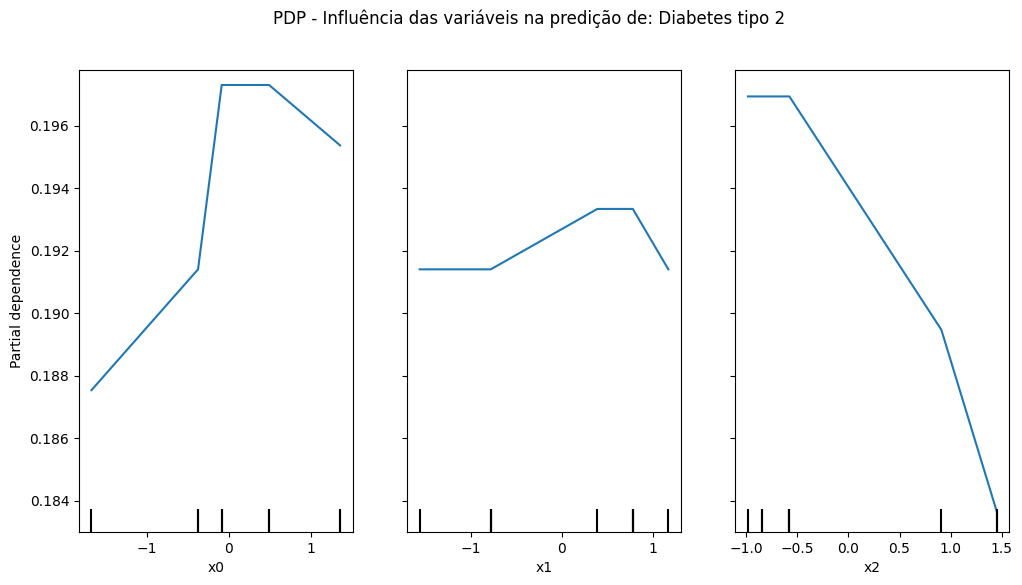

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

classe_desejada = "Diabetes tipo 2"

fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    clf,
    X,
    features=[0, 1, 2],
    target=classe_desejada,
    ax=ax
)
plt.suptitle(f"PDP - Influência das variáveis na predição de: {classe_desejada}")
plt.show()


## Exemplo reduzido para estimar acuracia com variação nos campos
 - não precisa do Hermes API

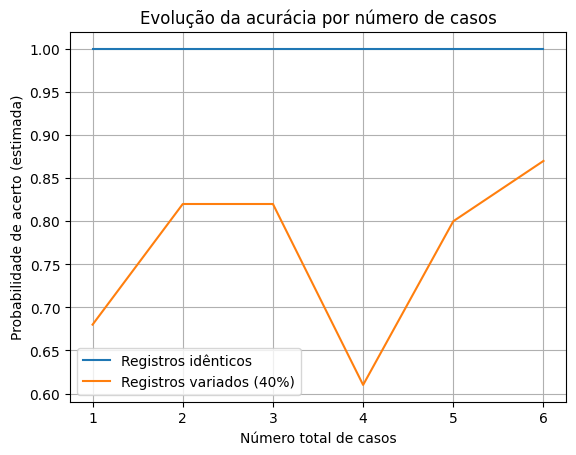

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import random

def gerar_textos_similares(base_texto, n, variacao=0.0):
    textos = []
    for _ in range(n):
        if variacao == 0:
            textos.append(base_texto)
        else:
            palavras = base_texto.split()
            n_palavras_alteradas = int(len(palavras) * variacao)
            for i in range(n_palavras_alteradas):
                idx = random.randint(0, len(palavras)-1)
                palavras[idx] = palavras[idx][::-1] 
            textos.append(" ".join(palavras))
    return textos

def simular_acuracia_por_similaridade(textos):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(textos)
    sim_matrix = cosine_similarity(tfidf_matrix)
    medias = []

    for i in range(len(textos)):
        similares = np.delete(sim_matrix[i], i)
        medias.append(similares.mean() if len(similares) > 0 else 0)

    acuracias = [round(min(1.0, m * 1.5), 2) for m in medias]
    return acuracias, medias

anos = [1, 2, 3, 4, 5]
casos_por_ano = [1, 1, 1, 1, 2]
base_texto = "Paciente com histórico familiar de doença genética rara e sintomas respiratórios persistentes"

textos_id = []
for c in casos_por_ano:
    textos_id.extend(gerar_textos_similares(base_texto, c, variacao=0.0))
acertos_id, sim_id = simular_acuracia_por_similaridade(textos_id)

textos_var = []
for c in casos_por_ano:
    textos_var.extend(gerar_textos_similares(base_texto, c, variacao=0.4))
acertos_var, sim_var = simular_acuracia_por_similaridade(textos_var)

# Gráfico
plt.plot(range(1, len(acertos_id)+1), acertos_id, label="Registros idênticos")
plt.plot(range(1, len(acertos_var)+1), acertos_var, label="Registros variados (40%)")
plt.xlabel("Número total de casos")
plt.ylabel("Probabilidade de acerto (estimada)")
plt.title("Evolução da acurácia por número de casos")
plt.legend()
plt.grid(True)
plt.show()


## Uso do MatplotLib para gerar graficos polinomiais

f(x) = 3.21364374056311e-15*x**4 + 10.3333333333333*x**3 - 103.0*x**2 + 318.666666666666*x - 225.999999999999
f'(x) = 1.28545749622524e-14*x**3 + 30.9999999999998*x**2 - 205.999999999999*x + 318.666666666666


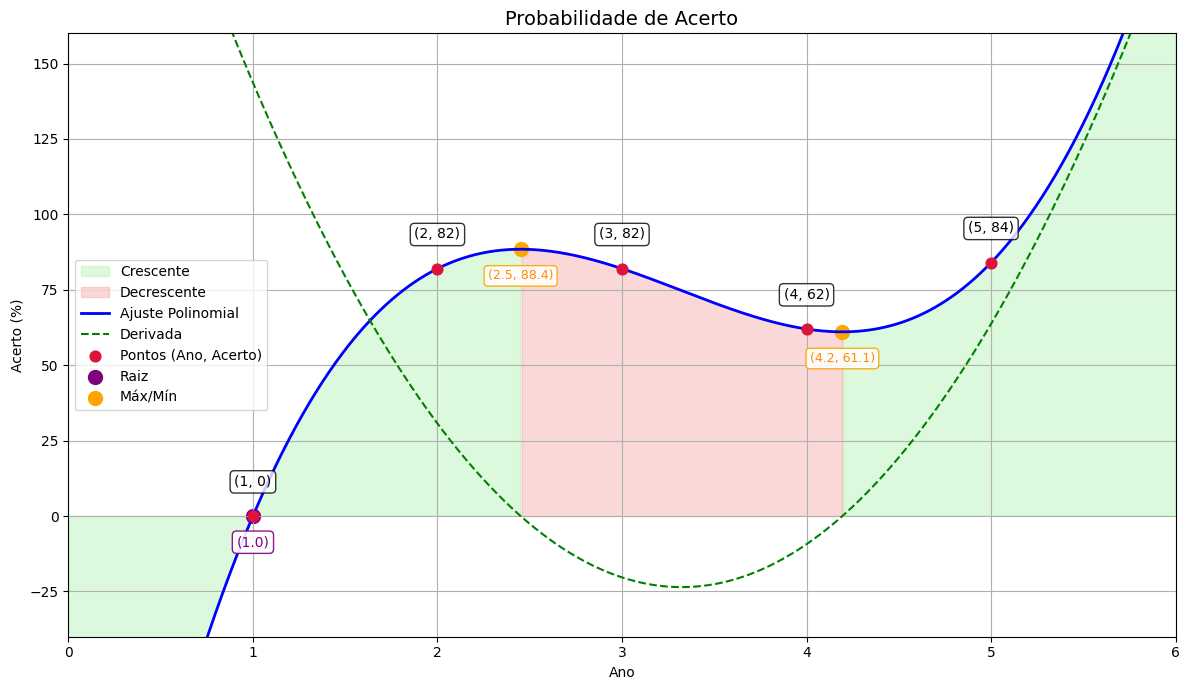

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import sympy as sp

def plot_polynomial_fit(
    grau=2,
    mostrar_derivada=False,
    mostrar_raizes=False,
    mostrar_extremos=False,
    mostrar_pontos=True,
    mostrar_regioes_positivas_negativas=False,
    x_central = 3,
    y_central = 60,
    x_margin = 3,
    y_margin = 100,
    linha = [1, 2, 3, 4, 5],
    coluna = [0, 82, 82, 62, 84]
):
    linha_np = np.array(linha)
    acertos_np = np.array(coluna)
    coef = np.polyfit(linha_np, acertos_np, grau)
    p = np.poly1d(coef)
    derivada = p.deriv()
    
    coefsp = np.polyfit(linha, coluna, grau)
    xsp = sp.Symbol('x')
    f_exprsp = sum(sp.Float(c)*xsp**i for i, c in enumerate(coefsp[::-1]))

    # Derivada simbólica
    d_exprsp = sp.diff(f_exprsp, xsp)

    # Mostrar formatado
    print("f(x) =", sp.simplify(f_exprsp))
    print("f'(x) =", sp.simplify(d_exprsp))

    x_vals = np.linspace(min(linha_np) - 1, max(linha_np) + 1, 1000)
    y_vals = p(x_vals)
    y_derivada = derivada(x_vals)

    plt.figure(figsize=(12, 7))

    if mostrar_regioes_positivas_negativas:
        crescente = y_derivada >= 0
        decrescente = y_derivada < 0
        plt.fill_between(x_vals, y_vals, where=crescente, color='lightgreen', alpha=0.3, label='Crescente')
        plt.fill_between(x_vals, y_vals, where=decrescente, color='lightcoral', alpha=0.3, label='Decrescente')

    plt.plot(x_vals, y_vals, label='Ajuste Polinomial', color='blue', linewidth=2)

    if mostrar_derivada:
        plt.plot(x_vals, y_derivada, label='Derivada', color='green', linestyle='--')

    if mostrar_pontos:
        plt.scatter(linha_np, acertos_np, color='crimson', label='Pontos (Ano, Acerto)', s=60, zorder=5)
        for x, y in zip(linha_np, acertos_np):
            plt.text(x, y  + 10, f'({x}, {y})',
                     fontsize=10, ha='center', color='black',
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

    if mostrar_raizes:
        raizes = p.r
        reais = raizes[np.isreal(raizes)].real
        for r in reais:
            if r < max(linha_np) + 1 and r > min(linha_np) - 1:
                y_r = p(r)
                plt.scatter(r, y_r, color='purple', marker='o', s=100, label='Raiz' if 'Raiz' not in plt.gca().get_legend_handles_labels()[1] else "")
                plt.text(r, y_r - 10, f'({r:.1f})',
                        fontsize=10, ha='center', color='purple',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='purple', alpha=0.9))

    if mostrar_extremos:
        deriv_raizes = derivada.r
        reais_deriv = deriv_raizes[np.isreal(deriv_raizes)].real
        for r in reais_deriv:
            if r < max(linha_np) + 1 and r > min(linha_np) - 1:
                y_r = p(r)
                plt.scatter(r, y_r, color='orange', marker='o', s=100, label='Máx/Mín' if 'Máx/Mín' not in plt.gca().get_legend_handles_labels()[1] else "")
                plt.text(r, y_r - 10, f'({r:.1f}, {y_r:.1f})',
                        fontsize=9, ha='center', color='darkorange',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='orange', alpha=0.9))
    plt.title("Probabilidade de Acerto", fontsize=14)
    plt.xlabel("Ano")
    plt.ylabel("Acerto (%)")
    plt.xlim(x_central - x_margin, x_central + x_margin)
    plt.ylim(y_central - y_margin, y_central + y_margin)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_polynomial_fit(
    grau=4,
    mostrar_derivada=True,
    mostrar_raizes=True,
    mostrar_extremos=True,
    mostrar_pontos=True,
    mostrar_regioes_positivas_negativas=True,
    x_central = 3,
    y_central = 60,
    x_margin = 3,
    y_margin = 100,
    linha = [1, 2, 3, 4, 5],
    coluna = [0, 82, 82, 62, 84]
)
